### Train T5

In [1]:
import sys
sys.path.append("..")
import utils
import p2t_utils

import pandas as pd
from datasets import Dataset, load_from_disk

In [2]:
# data = utils.load_data(path='../data/t15_copyTask_neuralData/hdf5_data_final/')

# train_dataset = p2t_utils.save_dataset_from_data(data, 'train', 'data/train_dataset')
# val_dataset = p2t_utils.save_dataset_from_data(data, 'val', 'data/val_dataset')

In [3]:
# p2t_utils.nltk.download('averaged_perceptron_tagger_eng')

# dataset = p2t_utils.load_dataset_and_process(limit=100000)

# print(f"Example Phonemes: {dataset[0]['phonemes']}")
# print(f"Example Text: {dataset[0]['text']}")

In [4]:
train_dataset = load_from_disk('data/train_dataset')
val_dataset = load_from_disk('data/val_dataset')

In [5]:
synthetic_dataset = load_from_disk('data/english_sentences')

Text(0.5, 1.0, 'Distribution of sentence lengths in phonemes')

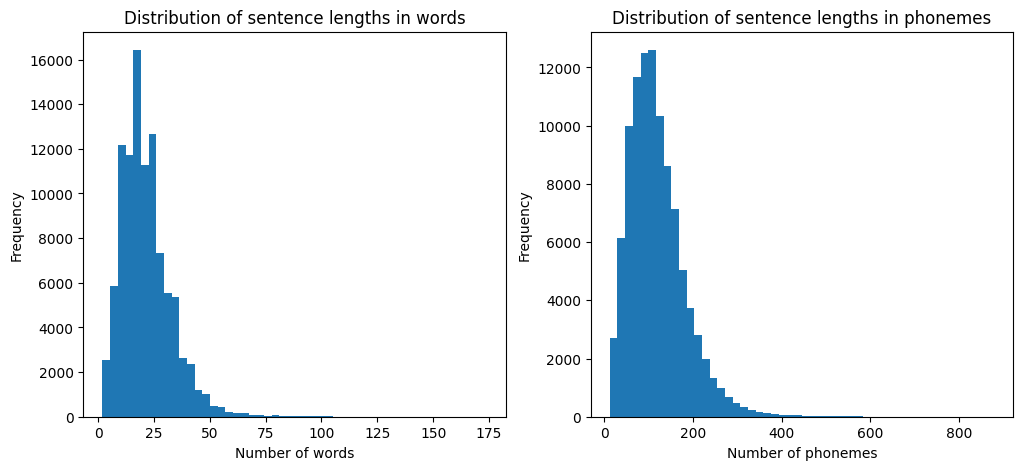

In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

w_lengths = [len(text.split()) for text in synthetic_dataset['text']]
ax1.hist(w_lengths, bins=50)
ax1.set_xlabel('Number of words')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of sentence lengths in words')

p_lengths = [len(p.split()) for p in synthetic_dataset['phonemes']]
ax2.hist(p_lengths, bins=50)
ax2.set_xlabel('Number of phonemes')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of sentence lengths in phonemes')

### Train T5 (Standard)
Training a standard T5 model (e.g., `t5-small`) for comparison. Note that T5 uses SentencePiece.

In [13]:
import torch
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments, T5ForConditionalGeneration, T5Tokenizer, DataCollatorForSeq2Seq
from datasets import load_from_disk

model_name = "t5-small"
tokenizer = T5Tokenizer.from_pretrained(model_name, model_max_length=1024)
model = T5ForConditionalGeneration.from_pretrained(model_name)

'(ProtocolError('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer')), '(Request ID: 9eb671f9-a47e-43ce-8549-d781a2367dda)')' thrown while requesting HEAD https://huggingface.co/t5-small/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].


In [14]:
tokenizer.save_pretrained('p2t_t5_tokenizer')
model.save_pretrained('p2t_t5_model')

In [ ]:
# T5 Training
import torch
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments, T5ForConditionalGeneration, T5Tokenizer, DataCollatorForSeq2Seq
from datasets import load_from_disk

# 1. Use English-only T5
model_name = "t5-small"
tokenizer = T5Tokenizer.from_pretrained(model_name, model_max_length=512)
model = T5ForConditionalGeneration.from_pretrained(model_name)

# 2. Add phonemes to vocab so they aren't "unknown"
tokenizer.add_tokens(utils.LOGIT_TO_PHONEME)
model.resize_token_embeddings(len(tokenizer))

# 2. Tokenization Function
PREFIX = "translate phonemes to english: "
def preprocess_function(examples):
    # Prepend the task prefix to every phoneme sequence
    cleaned_phonemes = [p.replace("BLANK", "").strip() for p in examples["phonemes"]]
    inputs = [PREFIX + str(p) for p in cleaned_phonemes]
    targets = [str(t) for t in examples["text"]]

    model_inputs = tokenizer(inputs, max_length=256, truncation=True, padding="max_length")
    labels = tokenizer(text_target=targets, max_length=128, truncation=True, padding="max_length")

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# 3. Prepare Dataset
dataset = load_from_disk("data/english_sentences")#.select(range(1000))
dataset = dataset.train_test_split(test_size=0.1)
tokenized_datasets = dataset.map(preprocess_function, batched=True)

# 4. Training Arguments
training_args = Seq2SeqTrainingArguments(
    output_dir="./phoneme_to_english_model",
    eval_strategy="epoch",
    learning_rate=5e-4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=5,
    predict_with_generate=True,
    generation_max_length=128,
    generation_num_beams=4,       # Use Beam Search for better eval results
    fp16=torch.cuda.is_available(),
)

# 5. Initialize Trainer
trainer = Seq2SeqTrainer(
    model=model,
    tokenizer=tokenizer,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=DataCollatorForSeq2Seq(tokenizer, model=model),
)

In [ ]:
trainer.train()
trainer.save_model("./phoneme_t5_prewashed")

In [ ]:
# Move to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

def translate_phonemes(phoneme_str):
    # 2. Prepare the input with the SAME prefix used in training
    prefix = "translate phonemes to english: "
    input_text = prefix + phoneme_str

    # 3. Tokenize
    inputs = tokenizer(input_text, return_tensors="pt").to(device)

    # 4. Generate with Beam Search
    output_sequences = model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_length=128,
        num_beams=5,             # Explore top 5 paths for better grammar
        early_stopping=True,
        no_repeat_ngram_size=2   # Prevents looping on the same words
    )

    # 5. Decode
    prediction = tokenizer.decode(output_sequences[0], skip_special_tokens=True)
    return prediction

# Example Test
test_phonemes = "N AA T | T UW | K AA N T R AH V ER SH AH L"
result = translate_phonemes(test_phonemes)
print(f"Input: {test_phonemes}")
print(f"Output: {result}")